In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the Titanic dataset
print("Loading Titanic Dataset...")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Loading Titanic Dataset...
Dataset Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123

In [19]:
print("="*80)
print("DATASET DESCRIPTION")
print("="*80)
print("""
Dataset Source: Titanic Dataset from Kaggle/GitHub
Dataset Contains: Information about passengers aboard the Titanic including:
- Survival status, passenger class, name, sex, age, siblings/spouses aboard,
- Parents/children aboard, ticket number, fare, cabin, and port of embarkation.

For this lab, we'll focus on:
- Numerical features: Age, Fare
- Categorical features: Survived, Pclass, Sex, Embarked
""")

print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

DATASET DESCRIPTION

Dataset Source: Titanic Dataset from Kaggle/GitHub
Dataset Contains: Information about passengers aboard the Titanic including:
- Survival status, passenger class, name, sex, age, siblings/spouses aboard,
- Parents/children aboard, ticket number, fare, cabin, and port of embarkation.

For this lab, we'll focus on:
- Numerical features: Age, Fare
- Categorical features: Survived, Pclass, Sex, Embarked

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    o

1. HISTOGRAMS FOR NUMERICAL DATA


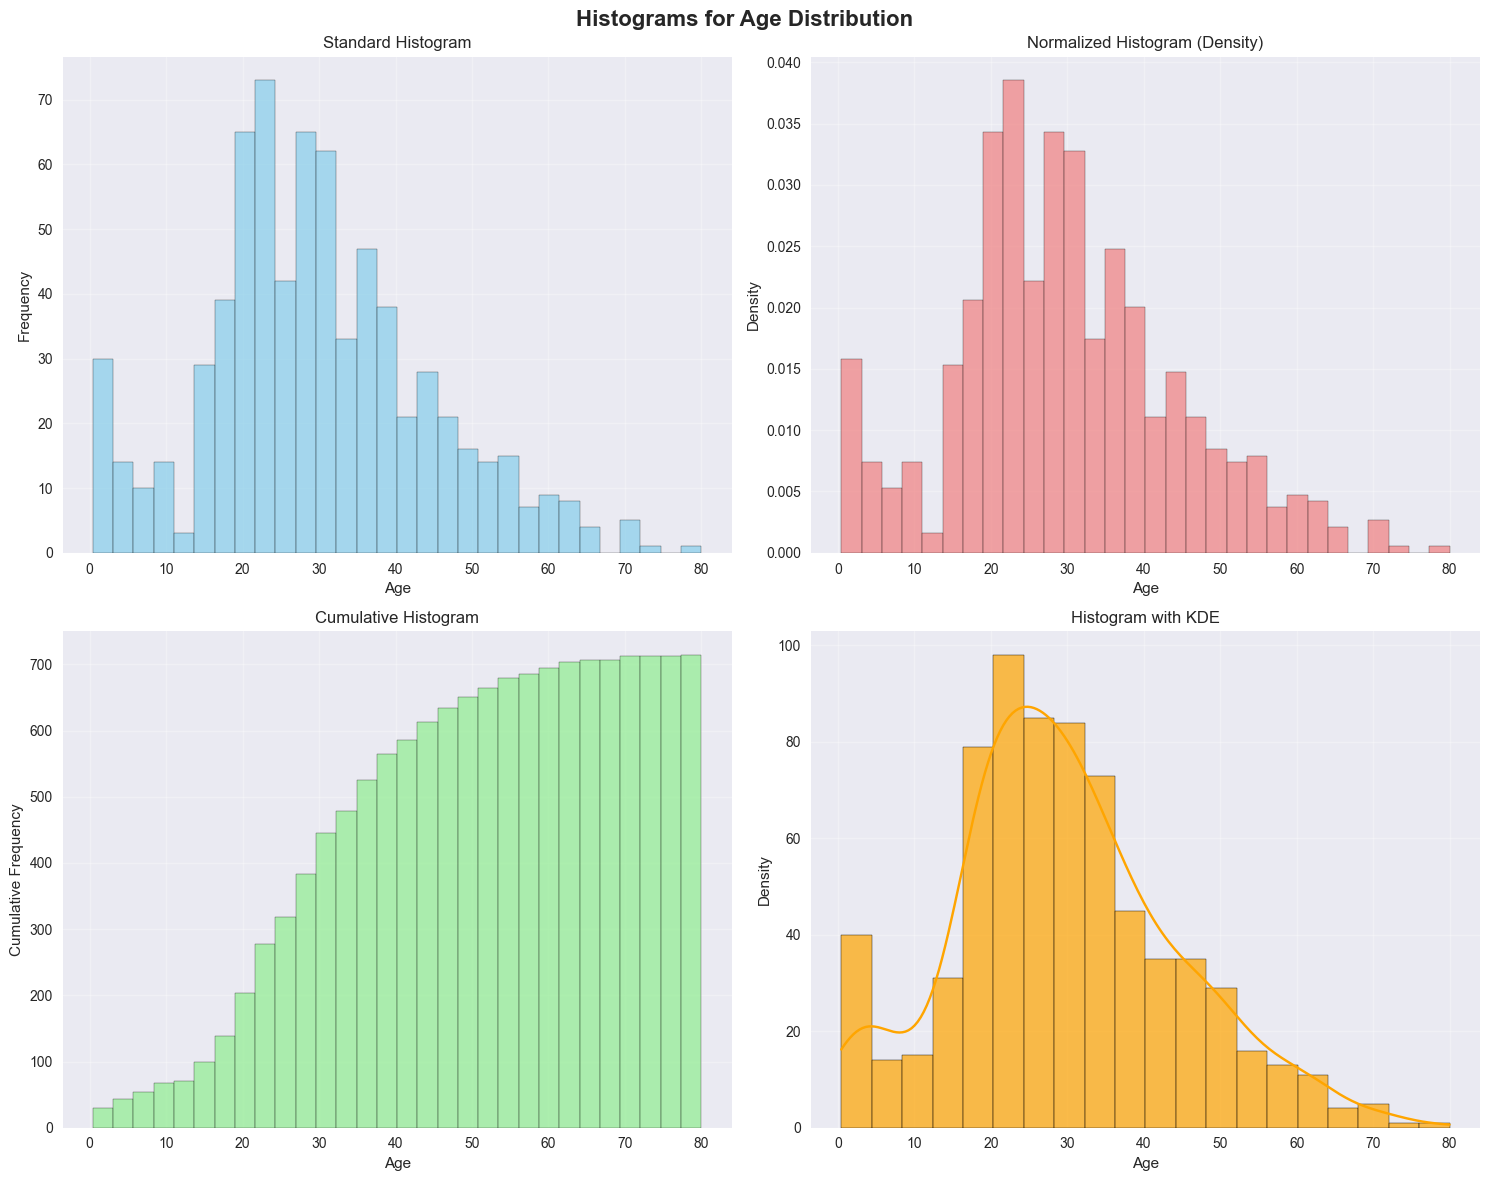


Feature Selected: Age (Numerical)
Analysis: The age distribution shows that most passengers were between 20-40 years old,
with a right-skewed distribution. The KDE overlay helps visualize the smooth density curve.
The cumulative histogram shows that about 50% of passengers were under 30 years old.



In [20]:
print("="*80)
print("1. HISTOGRAMS FOR NUMERICAL DATA")
print("="*80)

# Create a figure with subplots for histograms
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Histograms for Age Distribution', fontsize=16, fontweight='bold')

# 1.1 Standard Histogram
axes[0,0].hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Standard Histogram')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True, alpha=0.3)

# 1.2 Normalized Histogram
axes[0,1].hist(df['Age'].dropna(), bins=30, alpha=0.7, color='lightcoral', 
               density=True, edgecolor='black')
axes[0,1].set_title('Normalized Histogram (Density)')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Density')
axes[0,1].grid(True, alpha=0.3)

# 1.3 Cumulative Histogram
axes[1,0].hist(df['Age'].dropna(), bins=30, alpha=0.7, color='lightgreen', 
               cumulative=True, edgecolor='black')
axes[1,0].set_title('Cumulative Histogram')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Cumulative Frequency')
axes[1,0].grid(True, alpha=0.3)

# 1.4 KDE / Density Plot
sns.histplot(data=df, x='Age', kde=True, ax=axes[1,1], color='orange', alpha=0.7)
axes[1,1].set_title('Histogram with KDE')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Density')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Feature Selected: Age (Numerical)
Analysis: The age distribution shows that most passengers were between 20-40 years old,
with a right-skewed distribution. The KDE overlay helps visualize the smooth density curve.
The cumulative histogram shows that about 50% of passengers were under 30 years old.
""")

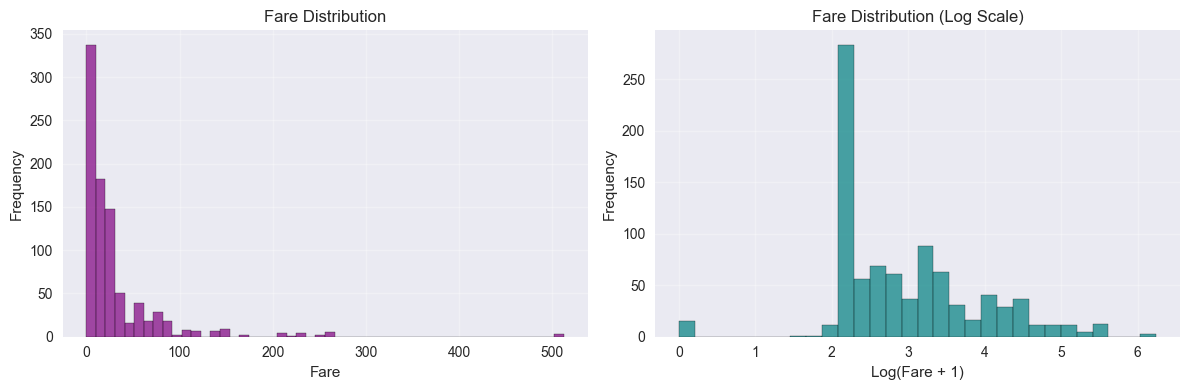


Feature Selected: Fare (Numerical)
Analysis: The fare distribution is highly right-skewed with most passengers paying low fares.
Using log transformation reveals a more normal-like distribution, indicating the presence
of different passenger classes with varying fare structures.



In [21]:
# Additional histogram for Fare
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Fare'].dropna(), bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Log scale for better visualization due to high skewness
plt.hist(np.log1p(df['Fare'].dropna()), bins=30, alpha=0.7, color='teal', edgecolor='black')
plt.title('Fare Distribution (Log Scale)')
plt.xlabel('Log(Fare + 1)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Feature Selected: Fare (Numerical)
Analysis: The fare distribution is highly right-skewed with most passengers paying low fares.
Using log transformation reveals a more normal-like distribution, indicating the presence
of different passenger classes with varying fare structures.
""")

2. BAR PLOTS FOR CATEGORICAL DATA


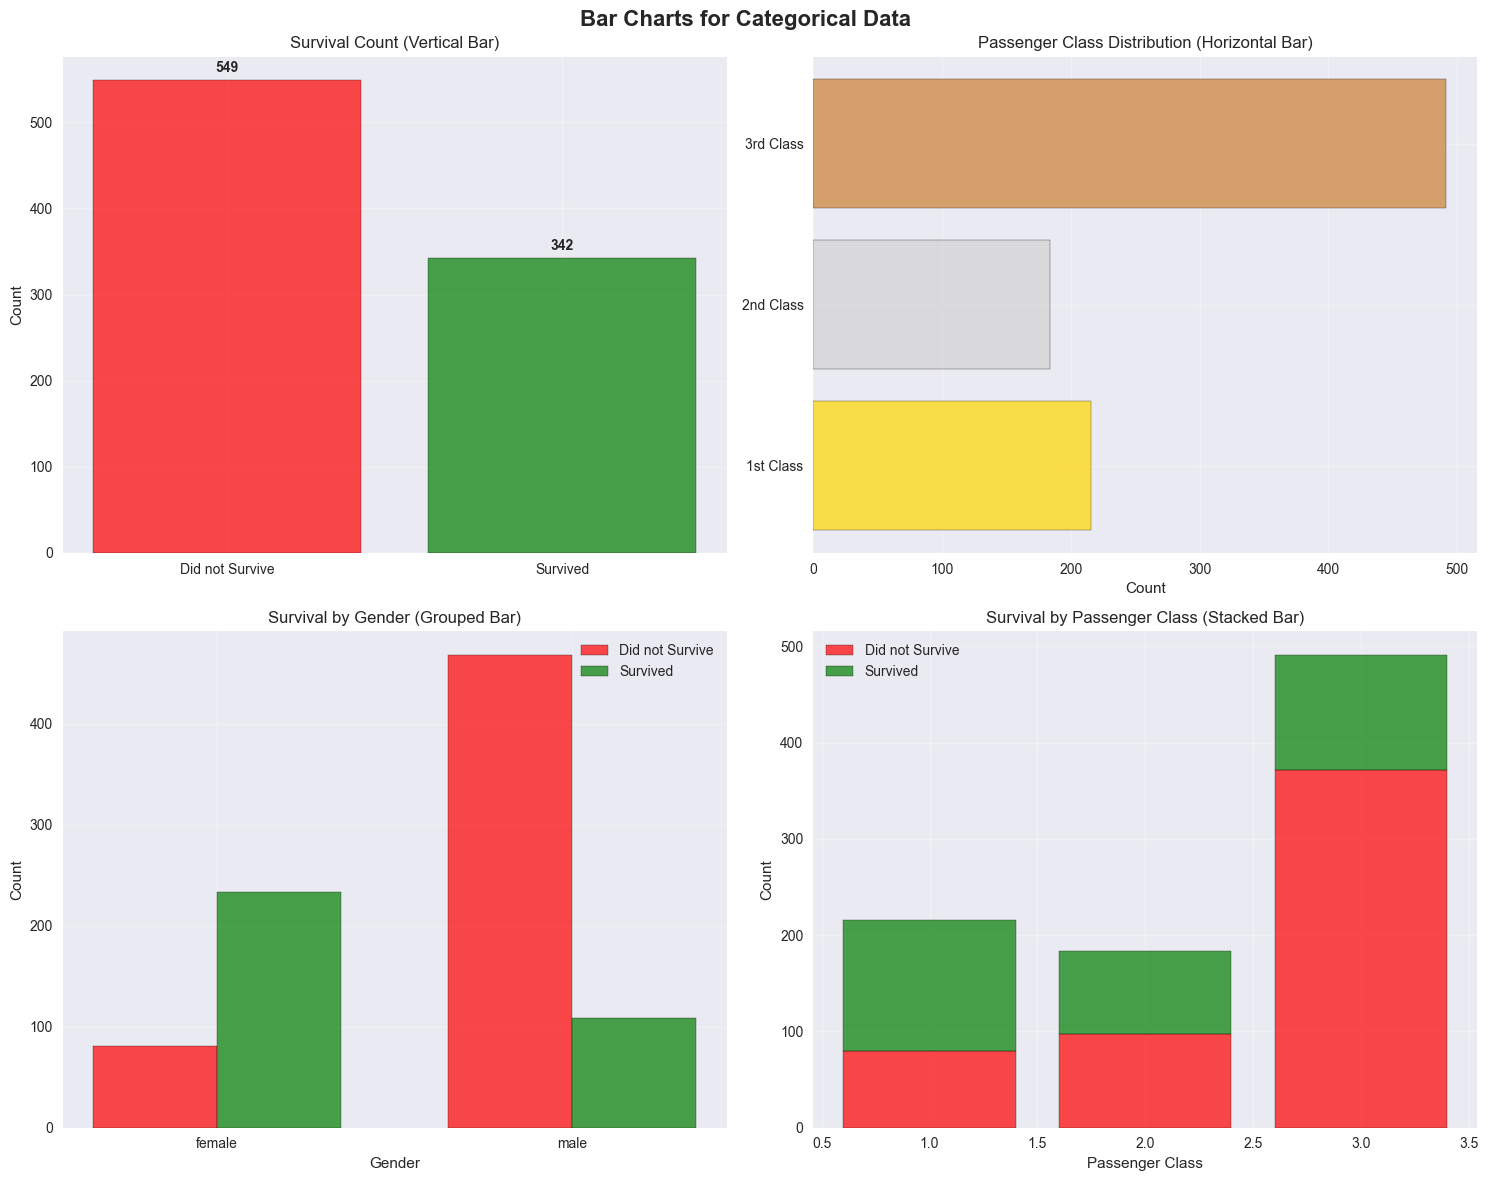

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109


In [24]:
print("="*80)
print("2. BAR PLOTS FOR CATEGORICAL DATA")
print("="*80)

# Create subplots for bar charts
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Bar Charts for Categorical Data', fontsize=16, fontweight='bold')

# 2.1 Vertical Bar Chart - Survival
survival_counts = df['Survived'].value_counts()
axes[0,0].bar(['Did not Survive', 'Survived'], survival_counts.values, 
              color=['red', 'green'], alpha=0.7, edgecolor='black')
axes[0,0].set_title('Survival Count (Vertical Bar)')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(survival_counts.values):
    axes[0,0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 2.2 Horizontal Bar Chart - Passenger Class (FIXED)
pclass_counts = df['Pclass'].value_counts().sort_index()
axes[0,1].barh(['1st Class', '2nd Class', '3rd Class'], pclass_counts.values, 
               color=['gold', 'lightgray', '#CD7F32'], alpha=0.7, edgecolor='black')
axes[0,1].set_title('Passenger Class Distribution (Horizontal Bar)')
axes[0,1].set_xlabel('Count')
axes[0,1].grid(True, alpha=0.3)

# 2.3 Grouped Bar Chart - Survival by Gender
survival_by_gender = pd.crosstab(df['Sex'], df['Survived'])
x = np.arange(len(survival_by_gender.index))
width = 0.35

axes[1,0].bar(x - width/2, survival_by_gender[0], width, label='Did not Survive', 
              color='red', alpha=0.7, edgecolor='black')
axes[1,0].bar(x + width/2, survival_by_gender[1], width, label='Survived', 
              color='green', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Survival by Gender (Grouped Bar)')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(survival_by_gender.index)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 2.4 Stacked Bar Chart - Survival by Class
survival_by_class = pd.crosstab(df['Pclass'], df['Survived'])
axes[1,1].bar(survival_by_class.index, survival_by_class[0], label='Did not Survive', 
              color='red', alpha=0.7, edgecolor='black')
axes[1,1].bar(survival_by_class.index, survival_by_class[1], 
              bottom=survival_by_class[0], label='Survived', 
              color='green', alpha=0.7, edgecolor='black')
axes[1,1].set_title('Survival by Passenger Class (Stacked Bar)')
axes[1,1].set_xlabel('Passenger Class')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Survival counts:")
print(survival_counts)
print("\nSurvival by Gender:")
print(survival_by_gender)

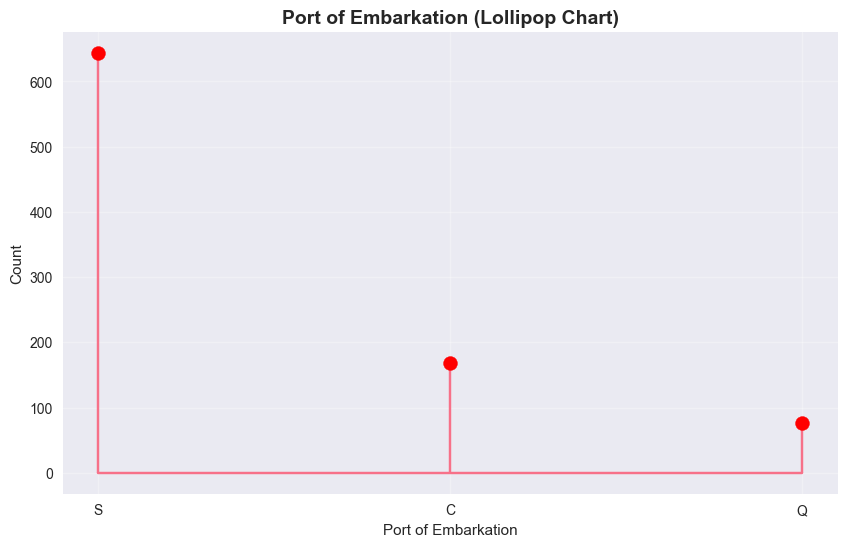

Port of Embarkation counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Features Selected: Survived, Pclass, Sex, Embarked (Categorical)
Analysis: The bar charts reveal important patterns:
- More passengers died than survived (549 vs 342)
- 3rd class had the most passengers, followed by 1st and 2nd class
- Gender significantly affected survival rates (more females survived)
- Most passengers embarked from Southampton (S), followed by Cherbourg (C) and Queenstown (Q)



In [ ]:
# Lollipop Chart
plt.figure(figsize=(10, 6))
embarked_counts = df['Embarked'].value_counts()
plt.stem(range(len(embarked_counts)), embarked_counts.values, basefmt='')
plt.scatter(range(len(embarked_counts)), embarked_counts.values, 
           color='red', s=100, zorder=3)
plt.title('Port of Embarkation (Lollipop Chart)', fontsize=14, fontweight='bold')
plt.xlabel('Port of Embarkation')
plt.ylabel('Count')
plt.xticks(range(len(embarked_counts)), embarked_counts.index)
plt.grid(True, alpha=0.3)
plt.show()

print("Port of Embarkation counts:")
print(embarked_counts)

print("""
Features Selected: Survived, Pclass, Sex, Embarked (Categorical)
Analysis: The bar charts reveal important patterns:
- More passengers died than survived (549 vs 342)
- 3rd class had the most passengers, followed by 1st and 2nd class
- Gender significantly affected survival rates (more females survived)
- Most passengers embarked from Southampton (S), followed by Cherbourg (C) and Queenstown (Q)
""")

3. PIE CHARTS FOR CATEGORY PROPORTIONS


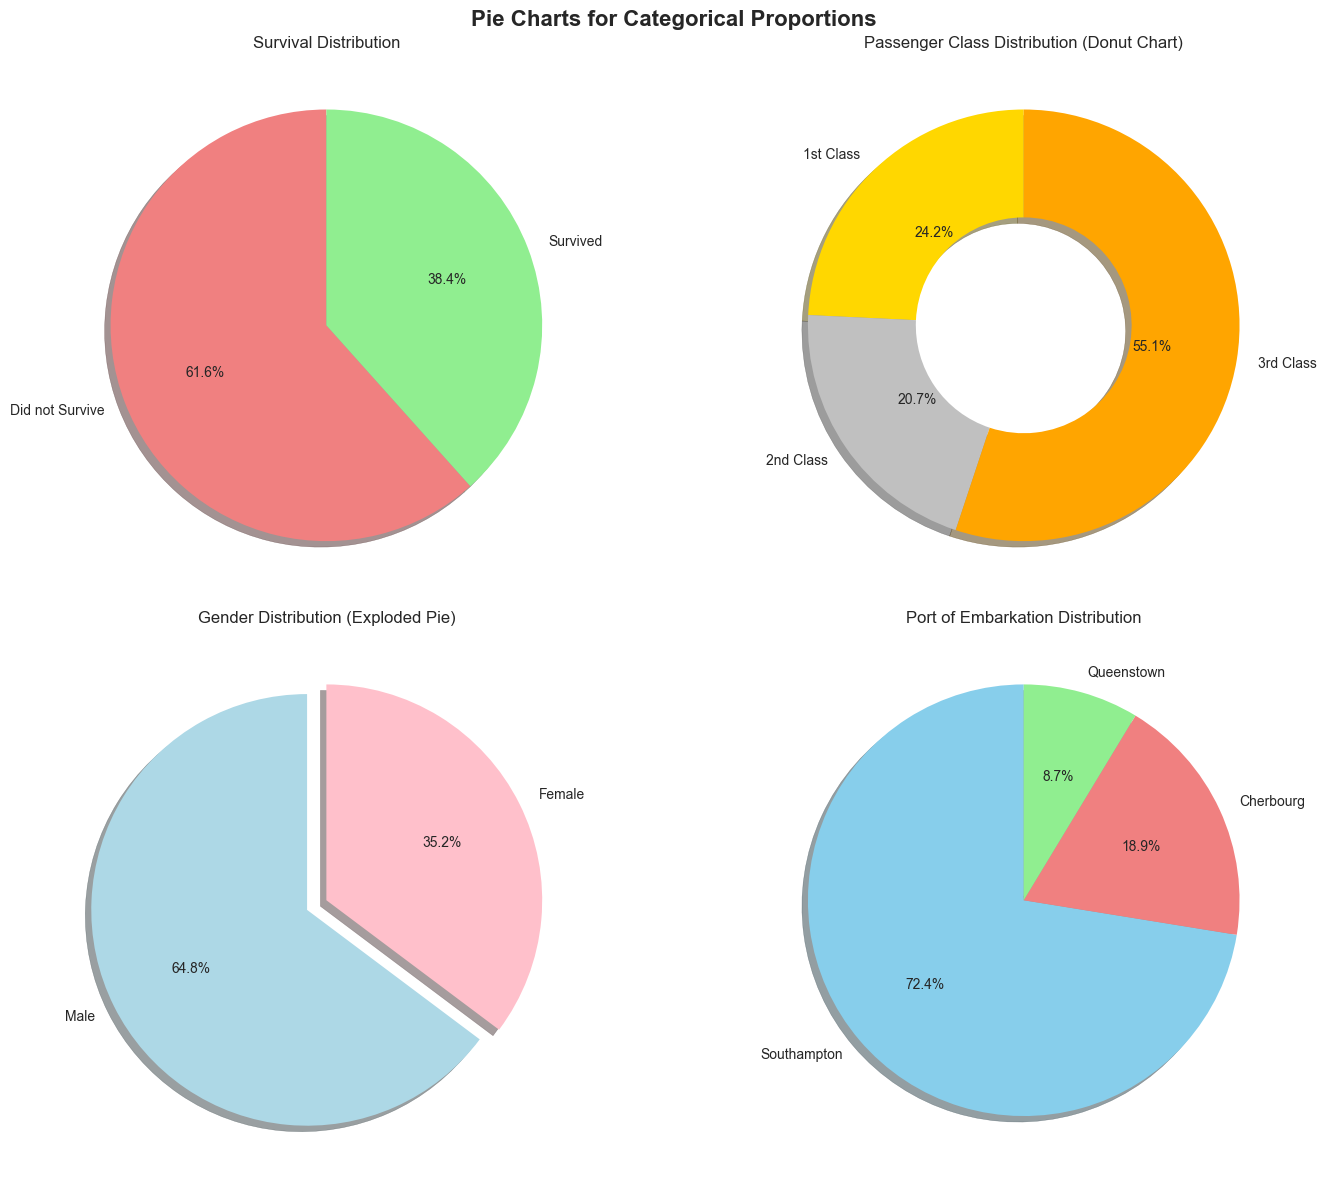

Proportional breakdown:
Survival rate: 38.4%
Gender distribution: Male 64.8%, Female 35.2%


In [ ]:
print("="*80)
print("3. PIE CHARTS FOR CATEGORY PROPORTIONS")
print("="*80)

# Create subplots for pie charts
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Pie Charts for Categorical Proportions', fontsize=16, fontweight='bold')

# 3.1 Standard Pie Chart - Survival
survival_counts = df['Survived'].value_counts()
labels = ['Did not Survive', 'Survived']
colors = ['lightcoral', 'lightgreen']
axes[0,0].pie(survival_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', 
              startangle=90, shadow=True)
axes[0,0].set_title('Survival Distribution')

# 3.2 Donut Chart - Passenger Class
pclass_counts = df['Pclass'].value_counts().sort_index()
labels = ['1st Class', '2nd Class', '3rd Class']
colors = ['gold', 'silver', 'orange']
wedges, texts, autotexts = axes[0,1].pie(pclass_counts.values, labels=labels, colors=colors, 
                                        autopct='%1.1f%%', startangle=90, 
                                        wedgeprops=dict(width=0.5), shadow=True)
axes[0,1].set_title('Passenger Class Distribution (Donut Chart)')

# 3.3 Exploded Pie Chart - Gender
gender_counts = df['Sex'].value_counts()
labels = ['Male', 'Female']
colors = ['lightblue', 'pink']
explode = (0.1, 0)  # explode male slice
axes[1,0].pie(gender_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', 
              startangle=90, explode=explode, shadow=True)
axes[1,0].set_title('Gender Distribution (Exploded Pie)')

# 3.4 Port of Embarkation Pie Chart
embarked_counts = df['Embarked'].value_counts()
labels = ['Southampton', 'Cherbourg', 'Queenstown']
colors = ['skyblue', 'lightcoral', 'lightgreen']
axes[1,1].pie(embarked_counts.values, labels=labels, colors=colors, autopct='%1.1f%%', 
              startangle=90, shadow=True)
axes[1,1].set_title('Port of Embarkation Distribution')

plt.tight_layout()
plt.show()

print("Proportional breakdown:")
print(f"Survival rate: {(survival_counts[1]/survival_counts.sum())*100:.1f}%")
print(f"Gender distribution: Male {(gender_counts['male']/gender_counts.sum())*100:.1f}%, Female {(gender_counts['female']/gender_counts.sum())*100:.1f}%")

In [ ]:
print("="*80)
print("4. BOX PLOTS FOR STATISTICAL SUMMARY")
print("="*80)

# Calculate and display statistical summary
age_stats = df['Age'].describe()
fare_stats = df['Fare'].describe()

print("AGE STATISTICS:")
print(f"Min: {age_stats['min']:.2f}")
print(f"Q1 (25th percentile): {age_stats['25%']:.2f}")
print(f"Q2 (Median/50th percentile): {age_stats['50%']:.2f}")
print(f"Q3 (75th percentile): {age_stats['75%']:.2f}")
print(f"Max: {age_stats['max']:.2f}")
print(f"Mean: {age_stats['mean']:.2f}")
print(f"Standard Deviation: {age_stats['std']:.2f}")

print("\nFARE STATISTICS:")
print(f"Min: {fare_stats['min']:.2f}")
print(f"Q1 (25th percentile): {fare_stats['25%']:.2f}")
print(f"Q2 (Median/50th percentile): {fare_stats['50%']:.2f}")
print(f"Q3 (75th percentile): {fare_stats['75%']:.2f}")
print(f"Max: {fare_stats['max']:.2f}")
print(f"Mean: {fare_stats['mean']:.2f}")
print(f"Standard Deviation: {fare_stats['std']:.2f}")

4. BOX PLOTS FOR STATISTICAL SUMMARY
AGE STATISTICS:
Min: 0.42
Q1 (25th percentile): 20.12
Q2 (Median/50th percentile): 28.00
Q3 (75th percentile): 38.00
Max: 80.00
Mean: 29.70
Standard Deviation: 14.53

FARE STATISTICS:
Min: 0.00
Q1 (25th percentile): 7.91
Q2 (Median/50th percentile): 14.45
Q3 (75th percentile): 31.00
Max: 512.33
Mean: 32.20
Standard Deviation: 49.69


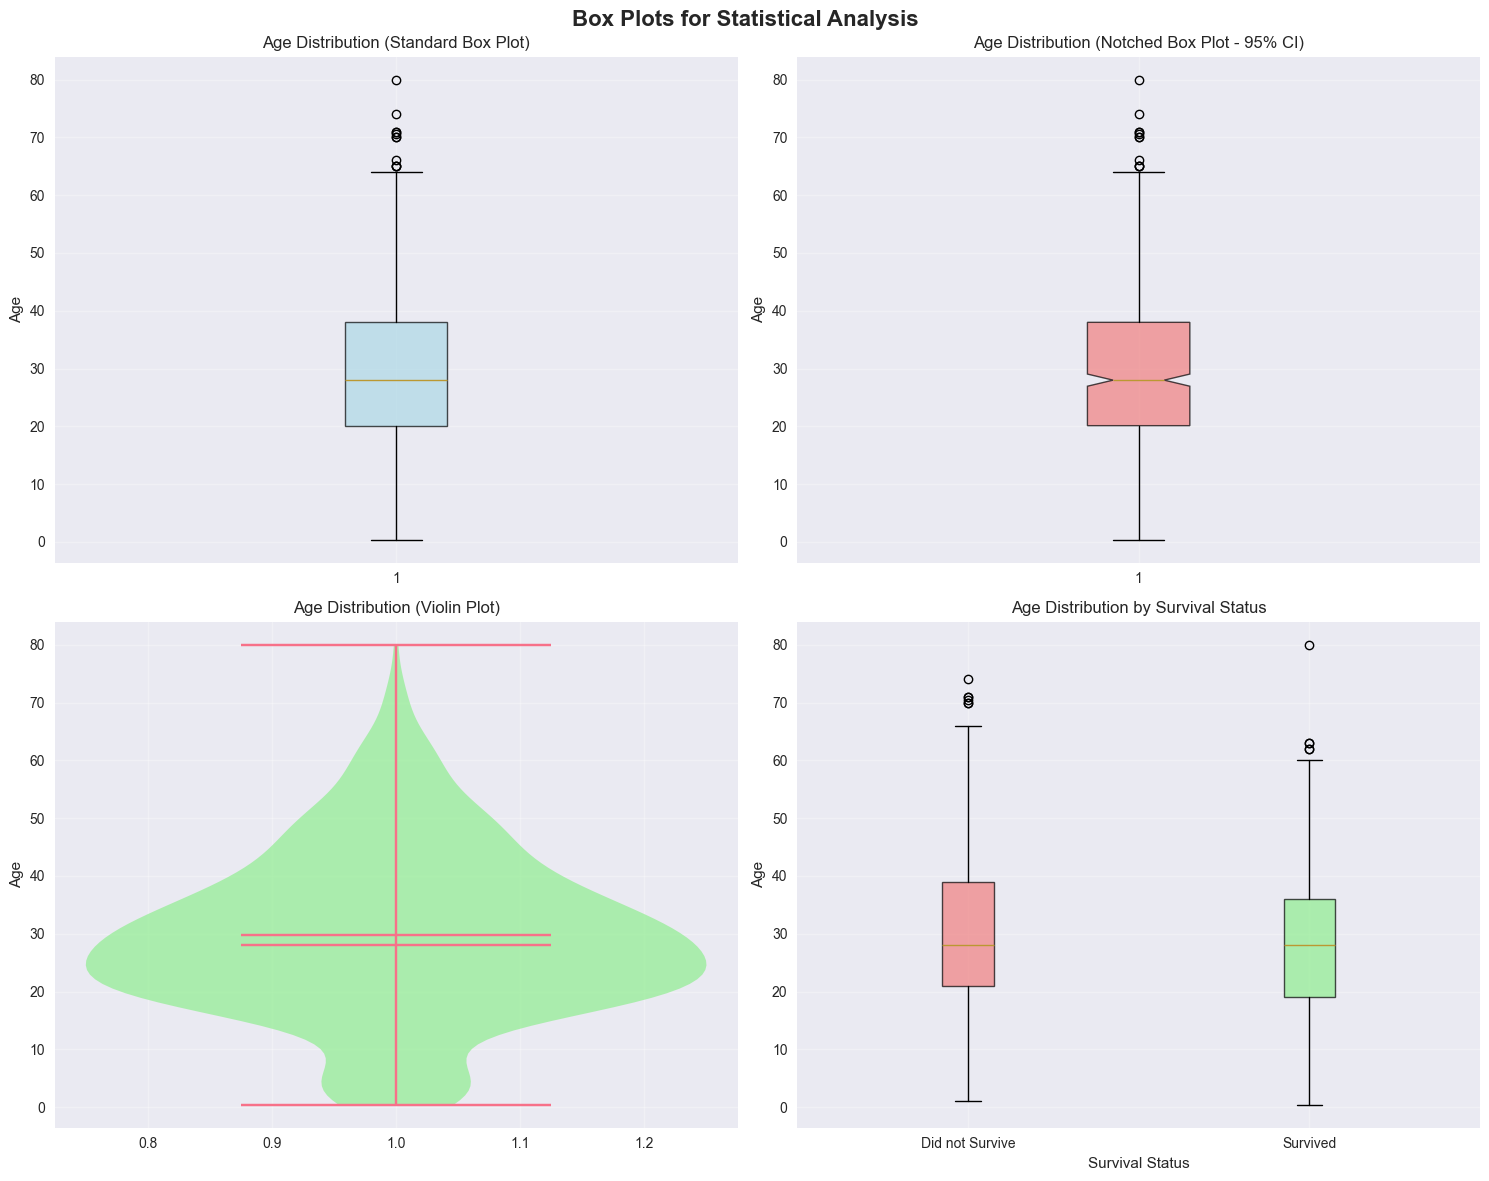

In [ ]:
# Create subplots for box plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Box Plots for Statistical Analysis', fontsize=16, fontweight='bold')

# 4.1 Standard Box Plot - Age
box1 = axes[0,0].boxplot(df['Age'].dropna(), patch_artist=True, 
                         boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0,0].set_title('Age Distribution (Standard Box Plot)')
axes[0,0].set_ylabel('Age')
axes[0,0].grid(True, alpha=0.3)

# 4.2 Notched Box Plot - Age (with 95% CI)
box2 = axes[0,1].boxplot(df['Age'].dropna(), patch_artist=True, notch=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7))
axes[0,1].set_title('Age Distribution (Notched Box Plot - 95% CI)')
axes[0,1].set_ylabel('Age')
axes[0,1].grid(True, alpha=0.3)

# 4.3 Violin Plot - Age
parts = axes[1,0].violinplot(df['Age'].dropna(), showmeans=True, showmedians=True)
axes[1,0].set_title('Age Distribution (Violin Plot)')
axes[1,0].set_ylabel('Age')
axes[1,0].grid(True, alpha=0.3)
# Color the violin plot
for pc in parts['bodies']:
    pc.set_facecolor('lightgreen')
    pc.set_alpha(0.7)

# 4.4 Side-by-side Box Plot - Age by Survival
survival_labels = ['Did not Survive', 'Survived']
age_by_survival = [df[df['Survived']==0]['Age'].dropna(), 
                   df[df['Survived']==1]['Age'].dropna()]
box4 = axes[1,1].boxplot(age_by_survival, labels=survival_labels, patch_artist=True)
axes[1,1].set_title('Age Distribution by Survival Status')
axes[1,1].set_xlabel('Survival Status')
axes[1,1].set_ylabel('Age')
axes[1,1].grid(True, alpha=0.3)

# Color the boxes differently
colors = ['lightcoral', 'lightgreen']
for patch, color in zip(box4['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

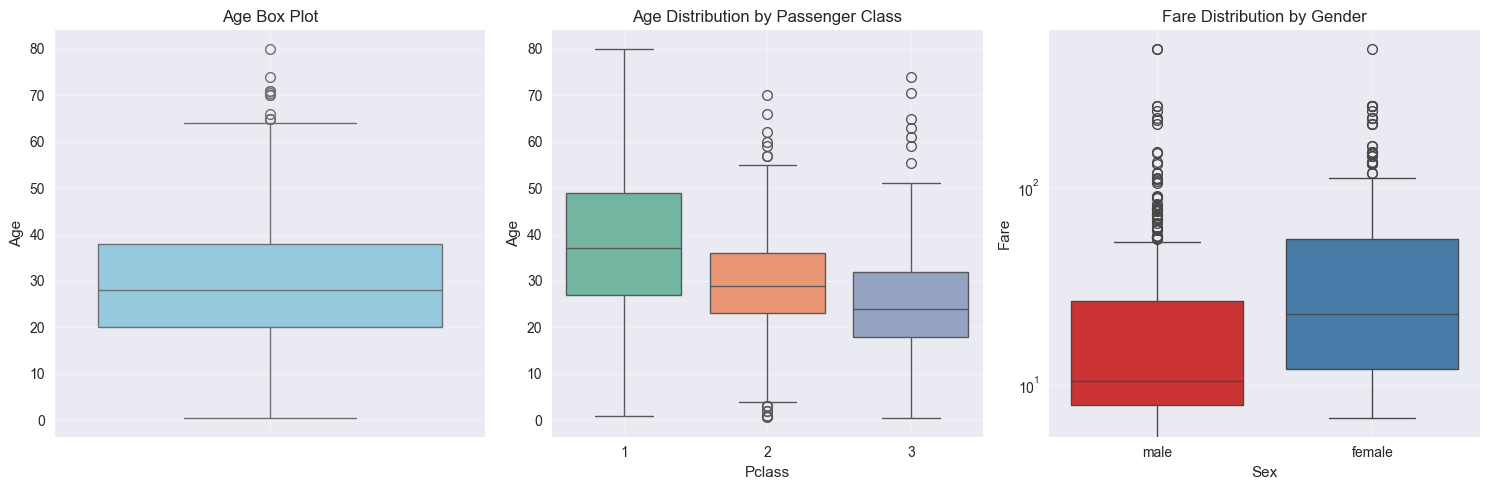


Features Selected: Age and Fare (Numerical) analyzed by Survived, Pclass, Sex (Categorical)
Analysis: The box plots reveal important statistical insights:
- Age: Median age was around 28 years, with several outliers (very young and old passengers)
- The notched box plot shows the confidence interval around the median
- Violin plots show the full distribution shape, revealing multiple peaks in age distribution
- Side-by-side comparisons show that survival rates varied slightly by age groups
- Fare distributions show extreme skewness, with 1st class passengers paying significantly more
- Gender differences in fare payments reflect the social structure of the time period



In [ ]:
# Additional box plots using seaborn for better styling
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, y='Age', color='skyblue')
plt.title('Age Box Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2')
plt.title('Age Distribution by Passenger Class')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Sex', y='Fare', palette='Set1')
plt.title('Fare Distribution by Gender')
plt.yscale('log')  # Log scale due to fare skewness
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Features Selected: Age and Fare (Numerical) analyzed by Survived, Pclass, Sex (Categorical)
Analysis: The box plots reveal important statistical insights:
- Age: Median age was around 28 years, with several outliers (very young and old passengers)
- The notched box plot shows the confidence interval around the median
- Violin plots show the full distribution shape, revealing multiple peaks in age distribution
- Side-by-side comparisons show that survival rates varied slightly by age groups
- Fare distributions show extreme skewness, with 1st class passengers paying significantly more
- Gender differences in fare payments reflect the social structure of the time period
""")